<a href="https://colab.research.google.com/github/lovita11/DataScience/blob/main/Pertemuan10_LovitaPrasetialestari_250401020061.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Nama : Lovita Prasetia Lestari

NIM : 2501020061

Kelas : IF403

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# ==========================================
# Langkah 1: Muat dan Eksplorasi Data
# ==========================================
url = "https://raw.githubusercontent.com/lovita11/DataScience/main/Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Ukuran dataset:", df.shape)
print("\nProporsi kelas churn:")
print(df["Churn"].value_counts(normalize=True))
df.head()

Ukuran dataset: (7043, 21)

Proporsi kelas churn:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ==========================================
# Langkah 2: Preprocessing
# ==========================================

from sklearn.model_selection import train_test_split

# Hapus kolom ID pelanggan
df_clean = df.drop(columns=["customerID"], errors="ignore")

# Pisahkan fitur dan target
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"].map({"No": 0, "Yes": 1})

# Ubah kolom kategorikal menjadi angka
X = pd.get_dummies(X, drop_first=True)

# Bagi data menjadi data latih dan data uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Ukuran Data Latih:", X_tr.shape)
print("Ukuran Data Uji:", X_te.shape)
print("Jumlah target kosong:", y.isna().sum())

Ukuran Data Latih: (5634, 6559)
Ukuran Data Uji: (1409, 6559)
Jumlah target kosong: 0


In [ ]:
# ==========================================
# Langkah 3: Latih Model
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_tr, y_tr)

print("Model berhasil dilatih")

Model berhasil dilatih


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score : 0.8301

Accuracy : 0.7934705464868701

=== Confusion Matrix ===
[[930 105]
 [186 188]]


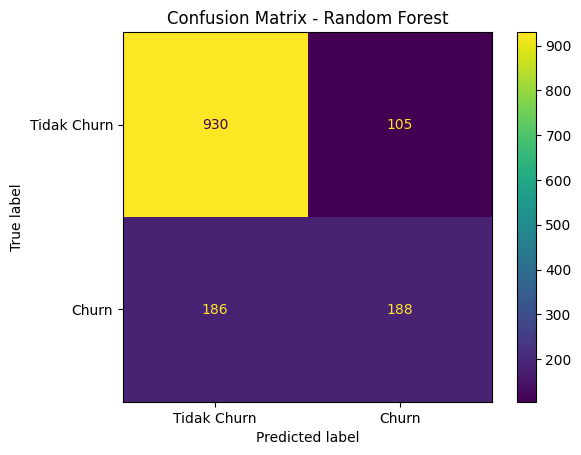


=== Evaluasi Metrik ===
Accuracy  : 0.7935
Precision : 0.6416
Recall    : 0.5027
F1-Score  : 0.5637


In [ ]:
# ==========================================
# Langkah 4 : Confusion Matrix dan Evaluasi Metrik
# ==========================================

from sklearn.metrics import classification_report, roc_auc_score

# Prediksi kelas
y_pred = rf.predict(X_te)

# Prediksi probabilitas kelas churn
y_prob = rf.predict_proba(X_te)[:, 1]

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_te, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_te, y_prob)

print("ROC-AUC Score :", round(roc_auc, 4))
print("\nAccuracy :", accuracy_score(y_te, y_pred))
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, y_pred)

print("\n=== Confusion Matrix ===")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Evaluasi metrik
precision = precision_score(y_te, y_pred)
recall = recall_score(y_te, y_pred)
f1 = f1_score(y_te, y_pred)

print("\n=== Evaluasi Metrik ===")
print(f"Accuracy  : {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

In [ ]:
# ==========================================
# Langkah 5 : Prediksi Probabilitas Churn
# ==========================================

print("\n=== Prediksi Probabilitas ===")
# Menambahkan hasil probabilitas ke dataframe pengujian
himpunan_uji = X_te.copy()
himpunan_uji["Probabilitas_Churn"] = y_prob
himpunan_uji["Prediksi_Churn"] = y_pred
print(himpunan_uji[["Probabilitas_Churn", "Prediksi_Churn"]].head(10))


=== Prediksi Probabilitas ===
      Probabilitas_Churn  Prediksi_Churn
437             0.006667               0
2280            0.656667               1
2235            0.050000               0
4460            0.300000               0
3761            0.020000               0
5748            0.533333               1
3568            0.370000               0
2976            0.053333               0
5928            0.000000               0
1639            0.530000               1


Kesimpulan :

Pada praktikum Pertemuan 10, algoritma Random Forest digunakan untuk melakukan
klasifikasi customer churn. Dataset yang digunakan memiliki ketidakseimbangan kelas, yaitu sekitar 73,46% pelanggan tidak churn dan 26,54% pelanggan churn. Untuk menangani kondisi tersebut digunakan parameter class_weight='balanced' pada Random Forest.

Berdasarkan hasil evaluasi, model menghasilkan Accuracy sekitar 79%, Precision kelas churn sekitar 0,64, Recall sekitar 0,50, F1-Score sekitar 0,56, serta ROC-AUC sekitar 0,83. Hasil tersebut menunjukkan bahwa model memiliki kemampuan klasifikasi yang cukup baik, tetapi masih terdapat pelanggan churn yang belum berhasil dideteksi.

Pada kasus customer churn, Accuracy saja dapat menyesatkan karena dataset tidak seimbang. Oleh karena itu, Recall dan F1-Score penting untuk diperhatikan agar kemampuan model dalam mendeteksi pelanggan yang benar-benar churn dapat dinilai dengan lebih baik.

Keterbatasan model adalah nilai Recall kelas churn yang masih sekitar 0,50. Model masih dapat dikembangkan melalui tuning hyperparameter atau metode penanganan imbalanced dataset lainnya agar kemampuan mendeteksi pelanggan churn meningkat.